# Cat vs Dog Classification with Transfer Learning
This notebook walks through the dataset, training pipeline, and evaluation results for the Cats vs Dogs image classification project.

In [6]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
sys.path.append(str(project_root / 'src'))

import matplotlib.pyplot as plt
from data_loader import get_class_counts
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

## Environment and Dataset Overview
The dataset is stored in `../Dataset` and contains the two classes `Cat` and `Dog`. We use transfer learning with a ResNet18 backbone trained on ImageNet.

In [7]:
data_dir = project_root / 'Dataset'
counts = get_class_counts(data_dir)
print('Dataset root:', data_dir)
print('Class counts:')
for label, count in counts.items():
    print(f'  {label}: {count}')

Dataset root: C:\Users\USER\Desktop\NEW\cnn_project\Dataset
Class counts:
  0: 12499
  1: 12499


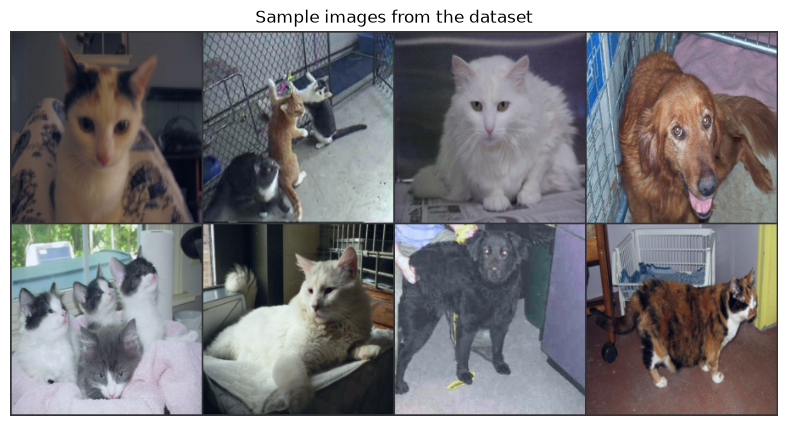

Classes: ['Cat', 'Dog']


In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
dataset = ImageFolder(str(data_dir), transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
images, labels = next(iter(loader))
grid = make_grid(images[:8], nrow=4, normalize=True, pad_value=0.2)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title('Sample images from the dataset')
plt.axis('off')
plt.show()
print('Classes:', dataset.classes)

## Training the model
The next step is to train the model using the implementation in `src/train.py`. The script performs dataset splitting, transfer learning, and logs training performance.

In [ ]:
!{sys.executable} ../src/train.py --data-dir ../Dataset --output-dir ../results --epochs 3 --batch-size 32 --feature-extract

^C


Using device: cpu
Dataset classes: ['Cat', 'Dog']
Training/Validation/Test split: (17500, 3749, 3749)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
Trainable parameters: 1026
Epoch 1/5: train_loss=0.4838, train_acc=0.7586, val_loss=0.1581, val_acc=0.9651
Saved best model to ..\results\best_model.pth
Epoch 2/5: train_loss=0.2922, train_acc=0.8732, val_loss=0.1082, val_acc=0.9720
Saved best model to ..\results\best_model.pth
Epoch 3/5: train_loss=0.2522, train_acc=0.8901, val_loss=0.0878, val_acc=0.9755
Saved best model to ..\results\best_model.pth
Epoch 4/5: train_loss=0.2311, train_acc=0.9007, val_loss=0.0753, val_acc=0.9800
Saved best model to ..\results\best_model.pth
Epoch 5/5: train_loss=0.2249, train_acc=0.9025, val_loss=0.0732, val_acc=0.9781
Training complete. History saved to ..\results\training_history.json



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
  0%|          | 128k/44.7M [00:00<03:17, 237kB/s]
  1%|          | 256k/44.7M [00:00<01:53, 412kB/s]
  1%|          | 384k/44.7M [00:00<01:26, 535kB/s]
  1%|          | 512k/44.7M [00:01<01:28, 525kB/s]
  2%|▏         | 768k/44.7M [00:01<00:57, 803kB/s]
  3%|▎         | 1.12M/44.7M [00:01<00:50, 897kB/s]
  3%|▎         | 1.38M/44.7M [00:02<01:03, 717kB/s]
  4%|▍         | 1.75M/44.7M [00:02<00:55, 810kB/s]
  4%|▍         | 2.00M/44.7M [00:03<01:04, 693kB/s]
  6%|▌         | 2.50M/44.7M [00:03<00:39, 1.11MB/s]
  6%|▌         | 2.75M/44.7M [00:03<00:46, 955kB/s] 
  7%|▋         | 3.12M/44.7M [00:03<00:35, 1.24MB/s]
  8%|▊         | 3.38M/44.7M [00:04<00:41, 1.04MB/s]
  8%|▊         | 3.62M/44.7M [00:04<00:59, 726kB/s] 
  9%|▊         | 3.88M/44.7M [00:05<01:03, 679kB/s]
 10%|█         | 4.62M/44.7M [00:05<00:32, 1.29MB/s]
 11%|█         | 4.88M/44.7M [00:06<00:54, 761kB/s] 
 12%|█▏        | 5.38M/44.7M [00:06<00:45, 900kB/s]
 13%|█▎        | 

Using device: cpu
Dataset classes: ['Cat', 'Dog']
Training/Validation/Test split: (17500, 3749, 3749)
Trainable parameters: 1026
Epoch 1/3: train_loss=0.4516, train_acc=0.7783, val_loss=0.1596, val_acc=0.9629
Saved best model to ..\results\best_model.pth
Epoch 2/3: train_loss=0.2882, train_acc=0.8743, val_loss=0.1042, val_acc=0.9728
Saved best model to ..\results\best_model.pth
Epoch 3/3: train_loss=0.2513, train_acc=0.8907, val_loss=0.0868, val_acc=0.9755
Saved best model to ..\results\best_model.pth
Training complete. History saved to ..\results\training_history.json


c:\Users\USER\Desktop\NEW\cnn_project\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\USER\Desktop\NEW\cnn_project\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
c:\Users\USER\Desktop\NEW\cnn_project\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
c:\Users\USER\Desktop\NEW\cnn_project\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


## Evaluation
After training, evaluate the best model on the held-out test split and inspect the confusion matrix.

In [4]:
!python ../src/evaluate.py --data-dir ../Dataset --weights ../results/best_model.pth --output-dir ../results

Using device: cpu
Evaluation Results
------------------
              precision    recall  f1-score   support

         Cat     0.9766    0.9730    0.9748      1886
         Dog     0.9727    0.9764    0.9746      1863

    accuracy                         0.9747      3749
   macro avg     0.9747    0.9747    0.9747      3749
weighted avg     0.9747    0.9747    0.9747      3749

Saved confusion matrix to ..\results\confusion_matrix.png
Saved evaluation report to ..\results\evaluation_report.txt


c:\Users\USER\Desktop\NEW\cnn_project\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Notes
- The notebook demonstrates dataset loading, sample visualization, training invocation, and evaluation.
- For a full project report, see `report.md` and the saved evaluation artifacts in `results/`.